# Capítulo 3 — Primer flujo completo de Machine Learning

En este cuaderno vamos a recorrer, por primera vez, el flujo general de un proyecto de Machine Learning.

El objetivo no es estudiar en profundidad cada etapa, sino ver cómo se conectan entre sí: definir un problema, conseguir datos, explorarlos, elegir variables, separar datos, entrenar un modelo, evaluar resultados y comunicar una conclusión inicial.

En capítulos posteriores vamos a detenernos con más detalle en cada parte del proceso. Por ahora, este cuaderno funciona como un primer mapa práctico.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- reconocer las etapas principales de un flujo de Machine Learning;
- cargar y explorar un dataset sencillo;
- identificar variables de entrada y variable objetivo;
- separar datos para entrenamiento y prueba;
- entrenar un primer modelo con `scikit-learn`;
- obtener una evaluación inicial;
- escribir una conclusión simple y responsable sobre el resultado.

## 1. Definir el problema y cargar los datos

En este cuaderno trabajaremos con un dataset clásico llamado Iris.

El dataset contiene mediciones de flores. Para cada flor conocemos cuatro medidas: largo y ancho del sépalo, y largo y ancho del pétalo. También conocemos la especie a la que pertenece cada flor.

La pregunta que queremos responder es:

**¿Podemos usar las medidas de una flor para predecir a qué especie pertenece?**

Como la respuesta esperada es una categoría, estamos frente a un problema de clasificación. En este capítulo no vamos a estudiar todavía los modelos de clasificación en profundidad. Usaremos este ejemplo solamente para recorrer el flujo general de un proyecto de Machine Learning.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [20]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species_id"] = iris.target
df["species"] = df["species_id"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


El DataFrame ya está organizado en una forma familiar.

Cada fila representa una flor. Las primeras cuatro columnas contienen mediciones numéricas: largo y ancho del sépalo, y largo y ancho del pétalo.

La columna `species_id` representa la especie codificada como número. Esa será la variable objetivo, es decir, lo que queremos predecir.

La columna `species` contiene el nombre de la especie. Nos ayuda a leer y explorar los datos, pero no será usada como entrada del modelo.

## 2. Explorar el dataset

Antes de entrenar un modelo, conviene mirar los datos.

En esta primera exploración queremos responder preguntas simples:

¿Cuántas flores hay en el dataset?

¿Qué columnas tenemos?

¿Hay valores faltantes?

¿Cuántos ejemplos hay de cada especie?

Esta revisión inicial nos ayuda a entender el material con el que vamos a trabajar.

In [21]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 150
Columnas: 6


In [22]:
df.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species_id,0
species,0


In [23]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


La revisión inicial muestra que el dataset tiene 150 filas y 6 columnas.

No aparecen valores faltantes en ninguna columna, por lo que no necesitamos hacer una limpieza básica antes de continuar.

También vemos que las tres especies están equilibradas: hay 50 ejemplos de `setosa`, 50 de `versicolor` y 50 de `virginica`.

Esto no significa que el problema esté resuelto, pero sí nos indica que el dataset está ordenado y es adecuado para hacer un primer recorrido completo del flujo de trabajo.

## 3. Visualizar una relación entre variables

Una exploración inicial puede ayudarnos a ver si las variables contienen información útil.

Vamos a comparar el largo y el ancho del pétalo. Cada punto representa una flor, y el color indica la especie.

No estamos entrenando todavía el modelo. Solo estamos observando si parece haber algún patrón en los datos.

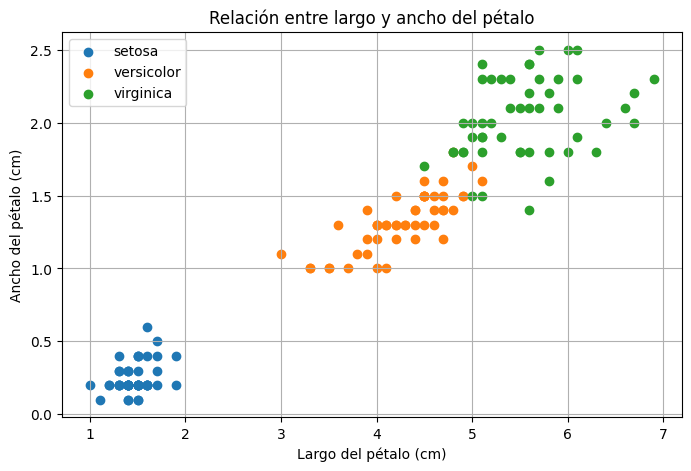

In [24]:
plt.figure(figsize=(8, 5))

for especie in df["species"].unique():
    datos_especie = df[df["species"] == especie]

    plt.scatter(
        datos_especie["petal length (cm)"],
        datos_especie["petal width (cm)"],
        label=especie
    )

plt.title("Relación entre largo y ancho del pétalo")
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.grid(True)
plt.legend()

plt.show()

El gráfico muestra que las especies no aparecen mezcladas por completo.

`setosa` queda bastante separada de las otras dos especies. `versicolor` y `virginica` están más cerca entre sí, aunque también muestran cierta diferencia.

Esta visualización sugiere que las medidas de los pétalos contienen información útil para distinguir especies. No alcanza para garantizar que un modelo funcionará bien, pero nos da una primera señal de que el problema tiene sentido.

## 4. Preparar variables de entrada y variable objetivo

Para entrenar un modelo necesitamos separar dos partes del dataset.

Por un lado, las variables de entrada: son los datos que el modelo podrá mirar para hacer una predicción.

Por otro lado, la variable objetivo: es la respuesta que queremos que el modelo aprenda a predecir.

En este ejemplo, usaremos las cuatro medidas de cada flor como variables de entrada, y la especie codificada como número como variable objetivo.

In [25]:
columnas_entrada = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

X = df[columnas_entrada]
y = df["species_id"]

In [26]:
print(f"X tiene {X.shape[0]} filas y {X.shape[1]} columnas.")
print(f"y tiene {y.shape[0]} valores.")

X tiene 150 filas y 4 columnas.
y tiene 150 valores.


La separación entre `X` e `y` es una de las ideas más importantes del flujo de Machine Learning.

`X` contiene la información que el modelo podrá usar para aprender. En este caso, son las cuatro medidas de cada flor.

`y` contiene la respuesta conocida. En este caso, es la especie de cada flor codificada como número.

En capítulos posteriores vamos a estudiar esta separación con más detalle. Por ahora alcanza con entender que el modelo intentará aprender una relación entre las medidas de las flores y sus especies.

## 5. Separar datos de entrenamiento y prueba

Para tener una primera idea de cómo funciona un modelo, no conviene entrenarlo y evaluarlo con exactamente los mismos datos.

Una práctica habitual es separar el dataset en dos partes:

una parte de entrenamiento, que el modelo usará para aprender;

una parte de prueba, que reservaremos para hacer una evaluación inicial.

En este capítulo solo usaremos esta separación como parte del flujo general. Más adelante vamos a estudiar con mayor cuidado por qué es tan importante.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


La salida muestra que usamos 120 ejemplos para entrenamiento y reservamos 30 ejemplos para prueba.

El modelo aprenderá usando `X_train` e `y_train`.

Luego haremos una primera evaluación usando `X_test` e `y_test`.

Esta separación es una forma simple de simular una situación importante: queremos saber si el modelo puede responder bien ante datos que no usó directamente para aprender.

## 6. Entrenar un primer modelo

Ahora vamos a entrenar un modelo de clasificación.

En este capítulo no nos interesa estudiar todavía cómo funciona internamente este modelo. Lo usaremos como una herramienta sencilla para completar el flujo de trabajo.

Más adelante estudiaremos modelos de clasificación con mayor detalle. Por ahora, alcanza con entender que el modelo recibe datos de entrenamiento y aprende una relación entre las medidas de las flores y sus especies.

La idea general es que el modelo observe ejemplos de flores con sus medidas y especies conocidas, y aprenda a relacionar esas medidas con cada especie.

In [28]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=5)

modelo.fit(X_train, y_train)

KNeighborsClassifier()

La salida confirma que el modelo quedó entrenado. El valor `n_neighbors=5` forma parte de la configuración del modelo. No necesitamos analizarlo todavía; lo retomaremos cuando estudiemos este tipo de modelo con más detalle.

La línea `modelo.fit(X_train, y_train)` es la que realiza el entrenamiento. Durante ese paso, el modelo usa las medidas de las flores de entrenamiento y sus especies conocidas.

Todavía no sabemos si el modelo funciona bien. Para eso necesitamos probarlo con datos que no haya usado durante el entrenamiento.

## 7. Hacer predicciones

Una vez entrenado el modelo, podemos pedirle que prediga la especie de las flores reservadas para prueba.

Estas flores no fueron usadas durante el entrenamiento. Por eso nos sirven para hacer una primera revisión del comportamiento del modelo ante datos nuevos.

In [29]:
predicciones = modelo.predict(X_test)

predicciones[:10]

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1])

In [30]:
nombres_predichos = pd.Series(predicciones).map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

nombres_predichos.head(10)

,0
0,setosa
1,virginica
2,versicolor
3,versicolor
4,setosa
5,versicolor
6,setosa
7,setosa
8,virginica
9,versicolor


Ahora las predicciones aparecen con nombres de especies.

Esto hace que el resultado sea más legible para una persona. Sin embargo, internamente el modelo trabajó con los códigos numéricos de `species_id`.

Ya tenemos predicciones. El siguiente paso del flujo es compararlas con las respuestas reales para obtener una primera idea de qué tan bien funcionó el modelo.

## 8. Evaluar el resultado

Después de hacer predicciones, necesitamos compararlas con las respuestas reales.

En este primer recorrido usaremos una métrica simple llamada `accuracy`, que indica la proporción de predicciones correctas.

No vamos a estudiar todavía todas sus ventajas y limitaciones. Por ahora, la usaremos como una primera forma de resumir qué tan bien funcionó el modelo sobre el conjunto de prueba.

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predicciones)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


La accuracy obtenida fue de `1.00`, es decir, el modelo acertó todas las predicciones del conjunto de prueba en esta ejecución.

Esto no significa que el modelo sea perfecto para cualquier caso real. Significa que, con esta separación específica de datos y este dataset sencillo, el modelo logró clasificar correctamente las flores reservadas para prueba.

En capítulos posteriores vamos a estudiar con más detalle cómo evaluar modelos, qué limitaciones puede tener una métrica como accuracy y por qué conviene analizar los resultados con más cuidado.

## 9. Comparar predicciones con respuestas reales

Para entender mejor el resultado, podemos construir una pequeña tabla comparando la especie real con la especie predicha por el modelo.

Esto nos permite ver algunos casos concretos del conjunto de prueba.

In [33]:
comparacion = pd.DataFrame({
    "real_id": y_test.values,
    "predicho_id": predicciones
})

comparacion["real"] = comparacion["real_id"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

comparacion["predicho"] = comparacion["predicho_id"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

comparacion.head(10)

,real_id,predicho_id,real,predicho
0,0,0,setosa,setosa
1,2,2,virginica,virginica
2,1,1,versicolor,versicolor
3,1,1,versicolor,versicolor
4,0,0,setosa,setosa
5,1,1,versicolor,versicolor
6,0,0,setosa,setosa
7,0,0,setosa,setosa
8,2,2,virginica,virginica
9,1,1,versicolor,versicolor


La tabla compara, caso por caso, la respuesta real con la predicción del modelo.

En estos primeros ejemplos, las columnas `real` y `predicho` coinciden. Eso es coherente con la accuracy obtenida anteriormente.

Esta comparación ayuda a recordar que una métrica resume muchos casos, pero detrás de ese número siempre hay predicciones individuales que pueden revisarse.

## 10. Usar el modelo con un caso nuevo

Una vez entrenado, el modelo puede recibir las medidas de una flor nueva y estimar a qué especie pertenece.

El siguiente ejemplo no proviene directamente del DataFrame original. Es un caso construido para ver cómo se usaría el modelo después del entrenamiento.

In [34]:
flor_nueva = pd.DataFrame({
    "sepal length (cm)": [5.1],
    "sepal width (cm)": [3.4],
    "petal length (cm)": [1.5],
    "petal width (cm)": [0.2]
})

flor_nueva

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.4,1.5,0.2


In [35]:
prediccion_nueva = modelo.predict(flor_nueva)

especie_predicha = pd.Series(prediccion_nueva).map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print(f"Especie predicha: {especie_predicha.iloc[0]}")

Especie predicha: setosa


El modelo predijo que la flor nueva pertenece a la especie `setosa`.

Este ejemplo muestra cómo podría usarse un modelo después de haber sido entrenado: recibe nuevas variables de entrada y devuelve una predicción.

De todos modos, la predicción debe interpretarse con cuidado. El modelo no “entiende” la flor como lo haría una persona. Solo usa los patrones aprendidos a partir de los datos de entrenamiento.

## 11. Comunicar una conclusión inicial

El último paso del flujo no es solo obtener un resultado, sino poder comunicarlo de manera clara y responsable.

En este primer recorrido podríamos escribir una conclusión como la siguiente:

Con el dataset Iris, construimos un primer modelo de clasificación para predecir la especie de una flor a partir de cuatro mediciones. El dataset no tenía valores faltantes y estaba equilibrado entre las tres especies. Luego separamos los datos en entrenamiento y prueba, entrenamos un modelo sencillo y obtuvimos una accuracy de 1.00 sobre el conjunto de prueba.

Este resultado indica que, en esta ejecución y con este dataset, el modelo clasificó correctamente todos los casos reservados para prueba. Sin embargo, no debemos interpretarlo como una garantía de funcionamiento perfecto en cualquier contexto. Para evaluar modelos con mayor seriedad, más adelante estudiaremos métricas, errores, validación y otras formas de análisis.

## Cierre del cuaderno

En este cuaderno recorrimos por primera vez un flujo completo de Machine Learning.

Definimos un problema, cargamos un dataset, exploramos sus características principales, separamos variables de entrada y variable objetivo, dividimos los datos en entrenamiento y prueba, entrenamos un modelo, hicimos predicciones, evaluamos el resultado y escribimos una conclusión inicial.

El objetivo no era dominar cada etapa en profundidad, sino ver cómo se conectan entre sí.

En los próximos capítulos vamos a volver sobre varias de estas etapas con más detalle. Primero estudiaremos con más cuidado cómo se organizan las variables de entrada y la variable objetivo, y luego veremos por qué la separación entre entrenamiento y prueba es tan importante.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Cuál era la pregunta que queríamos responder con el dataset Iris?
2. ¿Qué columnas usamos como variables de entrada?
3. ¿Cuál fue la variable objetivo?
4. ¿Por qué separamos datos de entrenamiento y datos de prueba?
5. ¿Por qué no conviene interpretar una accuracy de 1.00 como garantía de perfección?

Estas preguntas sirven para revisar el flujo general antes de estudiar cada etapa con mayor profundidad.